# Paso A: Cargar modelos e identificar tokens compartidos FR-ES

Cargamos los modelos Word2Vec (150D, CBOW, Wikipedia) para los tres niveles de granularidad:
- **Fonemas** (phoneme)
- **Fonestemas / Sílabas** (syllable)
- **Palabras** (word)

Identificamos los tokens compartidos entre FR y ES en cada nivel.

In [1]:
import sys
sys.path.insert(0, ".")

from loader import (load_all_models, load_all_frequencies, get_vocab,
                    get_shared_tokens, PHONEME_INVENTORY)
import pandas as pd
import numpy as np

models = load_all_models()
freqs = load_all_frequencies()
print("All models and frequency files loaded.")

All models and frequency files loaded.


## 1. Tamaño de vocabulario por nivel e idioma

In [2]:
rows = []
for level in ("phoneme", "syllable", "word"):
    for lang in ("es", "fr"):
        m = models[level][lang]
        # For phonemes, filter to real inventory; for others, use full vocab
        lang_filter = lang if level == "phoneme" else None
        vocab = get_vocab(m, lang=lang_filter)
        rows.append({
            "Nivel": level,
            "Idioma": lang.upper(),
            "Vocab size": len(vocab),
            "Embedding dim": m.wv.vector_size,
        })

vocab_df = pd.DataFrame(rows)
print("Note: phoneme vocab is filtered to actual language inventory (29 ES, 36 FR)")
vocab_df

Note: phoneme vocab is filtered to actual language inventory (29 ES, 36 FR)


,Nivel,Idioma,Vocab size,Embedding dim
0,phoneme,ES,29,150
1,phoneme,FR,36,150
2,syllable,ES,9848,150
3,syllable,FR,12433,150
4,word,ES,37291,150
5,word,FR,37269,150


## 2. Tokens compartidos FR-ES por nivel

Tokens que existen en el vocabulario de ambos idiomas (misma representacion IPA para fonemas/silabas, misma forma ortografica para palabras).

In [3]:
shared = {}
for level in ("phoneme", "syllable", "word"):
    lang_es = "es" if level == "phoneme" else None
    lang_fr = "fr" if level == "phoneme" else None
    
    es_vocab = get_vocab(models[level]["es"], lang=lang_es)
    fr_vocab = get_vocab(models[level]["fr"], lang=lang_fr)
    common = es_vocab & fr_vocab
    shared[level] = sorted(common)
    
    pct_es = len(common) / len(es_vocab) * 100
    pct_fr = len(common) / len(fr_vocab) * 100
    
    label = f"{level.upper()}" + (" (phoneme inventory)" if level == "phoneme" else "")
    print(f"--- {label} ---")
    print(f"  ES vocab: {len(es_vocab):,}")
    print(f"  FR vocab: {len(fr_vocab):,}")
    print(f"  Compartidos: {len(common):,} ({pct_es:.1f}% de ES, {pct_fr:.1f}% de FR)")
    print()

--- PHONEME (phoneme inventory) ---
  ES vocab: 29
  FR vocab: 36
  Compartidos: 20 (69.0% de ES, 55.6% de FR)

--- SYLLABLE ---
  ES vocab: 9,848
  FR vocab: 12,433
  Compartidos: 1,497 (15.2% de ES, 12.0% de FR)

--- WORD ---
  ES vocab: 37,291
  FR vocab: 37,269
  Compartidos: 6,827 (18.3% de ES, 18.3% de FR)



## 3. Detalle de fonemas compartidos

Los fonemas son un conjunto pequeno y manejable: mostramos todos los compartidos.

In [4]:
# Phonemes: show all shared with frequencies in both languages
freq_es_ph = freqs["phoneme"]["es"].set_index("token")["freq"]
freq_fr_ph = freqs["phoneme"]["fr"].set_index("token")["freq"]

ph_rows = []
for token in shared["phoneme"]:
    ph_rows.append({
        "Fonema": token,
        "Freq ES": freq_es_ph.get(token, 0),
        "Freq FR": freq_fr_ph.get(token, 0),
    })

ph_df = pd.DataFrame(ph_rows).sort_values("Freq ES", ascending=False)
print(f"Fonemas compartidos: {len(ph_df)}")
print(f"\nES-only: {sorted(get_vocab(models['phoneme']['es'], lang='es') - get_vocab(models['phoneme']['fr'], lang='fr'))}")
print(f"FR-only: {sorted(get_vocab(models['phoneme']['fr'], lang='fr') - get_vocab(models['phoneme']['es'], lang='es'))}")
ph_df

Fonemas compartidos: 20

ES-only: ['r', 't͡ʃ', 'x', 'ð', 'ɣ', 'ɾ', 'ʎ', 'β', 'θ']
FR-only: ['v', 'y', 'z', 'ø', 'œ', 'œ̃', 'ɑ̃', 'ɔ', 'ɔ̃', 'ə', 'ɛ', 'ɛ̃', 'ɥ', 'ʁ', 'ʃ', 'ʒ']


,Fonema,Freq ES,Freq FR
3,e,9757983,1956650
0,a,9139903,4600568
13,s,6984357,6196430
11,o,6825131,482587
10,n,5470524,2666244
5,i,5103301,3392366
8,l,4020619,3964168
2,d,3851219,3157997
14,t,3622499,4628125
7,k,2954362,2554432


## 4. Fonemas exclusivos de cada idioma

In [5]:
es_only_ph = get_vocab(models["phoneme"]["es"], lang="es") - get_vocab(models["phoneme"]["fr"], lang="fr")
fr_only_ph = get_vocab(models["phoneme"]["fr"], lang="fr") - get_vocab(models["phoneme"]["es"], lang="es")

print(f"Solo ES ({len(es_only_ph)}): {sorted(es_only_ph)}")
print("  (ð, ɣ, β = allophones lenited; θ = interdental; t͡ʃ = affricate; ʎ = lateral palatal; r = trill; x = velar fric.)")
print()
print(f"Solo FR ({len(fr_only_ph)}): {sorted(fr_only_ph)}")
print("  (nasal vowels ɑ̃ ɛ̃ ɔ̃ œ̃; rounded front y ø œ; uvular ʁ; labial-palatal ɥ; ə schwa; fricatives v z ʃ ʒ)")

Solo ES (9): ['r', 't͡ʃ', 'x', 'ð', 'ɣ', 'ɾ', 'ʎ', 'β', 'θ']
  (ð, ɣ, β = allophones lenited; θ = interdental; t͡ʃ = affricate; ʎ = lateral palatal; r = trill; x = velar fric.)

Solo FR (16): ['v', 'y', 'z', 'ø', 'œ', 'œ̃', 'ɑ̃', 'ɔ', 'ɔ̃', 'ə', 'ɛ', 'ɛ̃', 'ɥ', 'ʁ', 'ʃ', 'ʒ']
  (nasal vowels ɑ̃ ɛ̃ ɔ̃ œ̃; rounded front y ø œ; uvular ʁ; labial-palatal ɥ; ə schwa; fricatives v z ʃ ʒ)


## 5. Silabas (fonestemas) compartidas - Top 50 por frecuencia

Las silabas compartidas son el conjunto clave para el analisis fonestemico cross-linguistico.

In [6]:
freq_es_syl = freqs["syllable"]["es"].set_index("token")["freq"]
freq_fr_syl = freqs["syllable"]["fr"].set_index("token")["freq"]

syl_rows = []
for token in shared["syllable"]:
    syl_rows.append({
        "Silaba": token,
        "Freq ES": freq_es_syl.get(token, 0),
        "Freq FR": freq_fr_syl.get(token, 0),
    })

syl_df = pd.DataFrame(syl_rows)
syl_df["Freq Total"] = syl_df["Freq ES"] + syl_df["Freq FR"]
syl_df = syl_df.sort_values("Freq Total", ascending=False)

print(f"Silabas compartidas: {len(syl_df):,}")
print(f"\nTop 50 por frecuencia combinada:")
syl_df.head(50)

Silabas compartidas: 1,497

Top 50 por frecuencia combinada:


,Silaba,Freq ES,Freq FR,Freq Total
237,de,1451639,193824,1645463
685,la,799596,587098,1386694
1245,te,542006,219676,761682
0,a,317024,421835,738859
1117,si,378431,265711,644142
1224,ta,551543,90506,642049
1108,se,511285,129454,640739
530,ka,425074,139619,564693
1282,to,425194,106151,531345
1255,ti,355040,156433,511473


## 6. Visualizacion: Overlap de vocabularios por nivel

Diagrama de Venn conceptual mostrando el porcentaje de solapamiento.

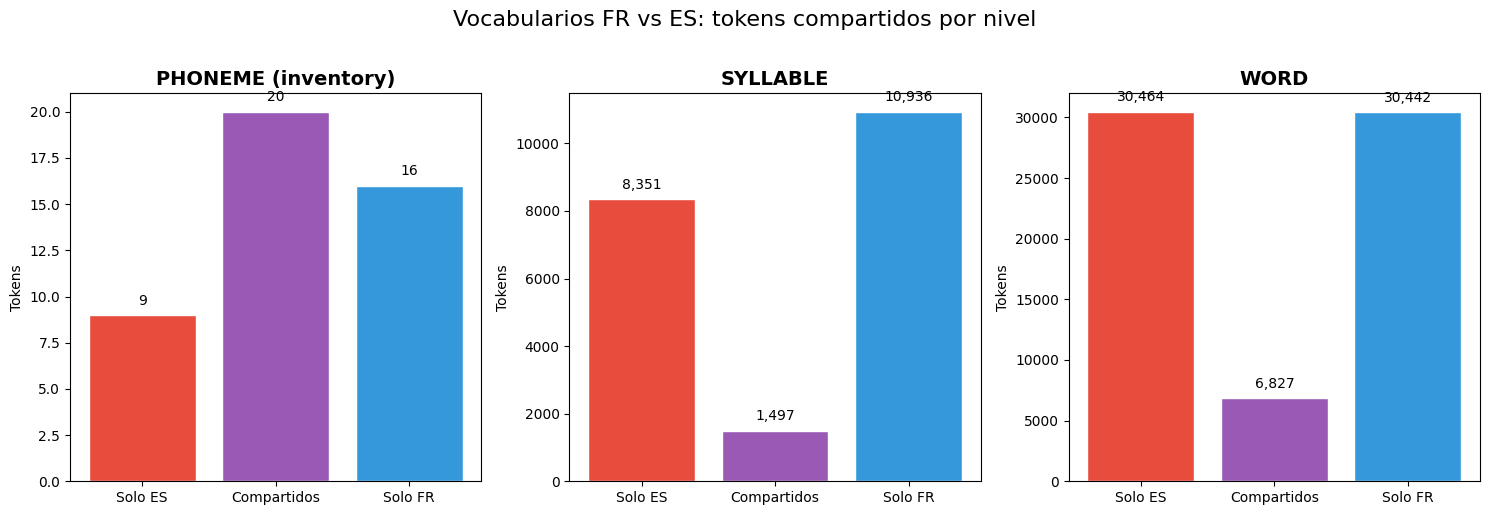

In [7]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, level in enumerate(("phoneme", "syllable", "word")):
    ax = axes[idx]
    lang_es = "es" if level == "phoneme" else None
    lang_fr = "fr" if level == "phoneme" else None
    es_v = get_vocab(models[level]["es"], lang=lang_es)
    fr_v = get_vocab(models[level]["fr"], lang=lang_fr)
    common = es_v & fr_v
    es_only = len(es_v) - len(common)
    fr_only = len(fr_v) - len(common)
    
    labels = ["Solo ES", "Compartidos", "Solo FR"]
    sizes = [es_only, len(common), fr_only]
    colors = ["#e74c3c", "#9b59b6", "#3498db"]
    
    bars = ax.bar(labels, sizes, color=colors, edgecolor="white")
    title = f"{level.upper()}"
    if level == "phoneme":
        title += " (inventory)"
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_ylabel("Tokens")
    
    for bar, size in zip(bars, sizes):
        ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + max(sizes)*0.02,
                f"{size:,}", ha="center", va="bottom", fontsize=10)

plt.suptitle("Vocabularios FR vs ES: tokens compartidos por nivel", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("vocab_overlap.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Correlacion de frecuencias: tokens compartidos

Para los tokens que existen en ambos idiomas, que tan correlacionadas estan sus frecuencias? Alta correlacion sugiere que los mismos fonemas/silabas son importantes en ambos idiomas.

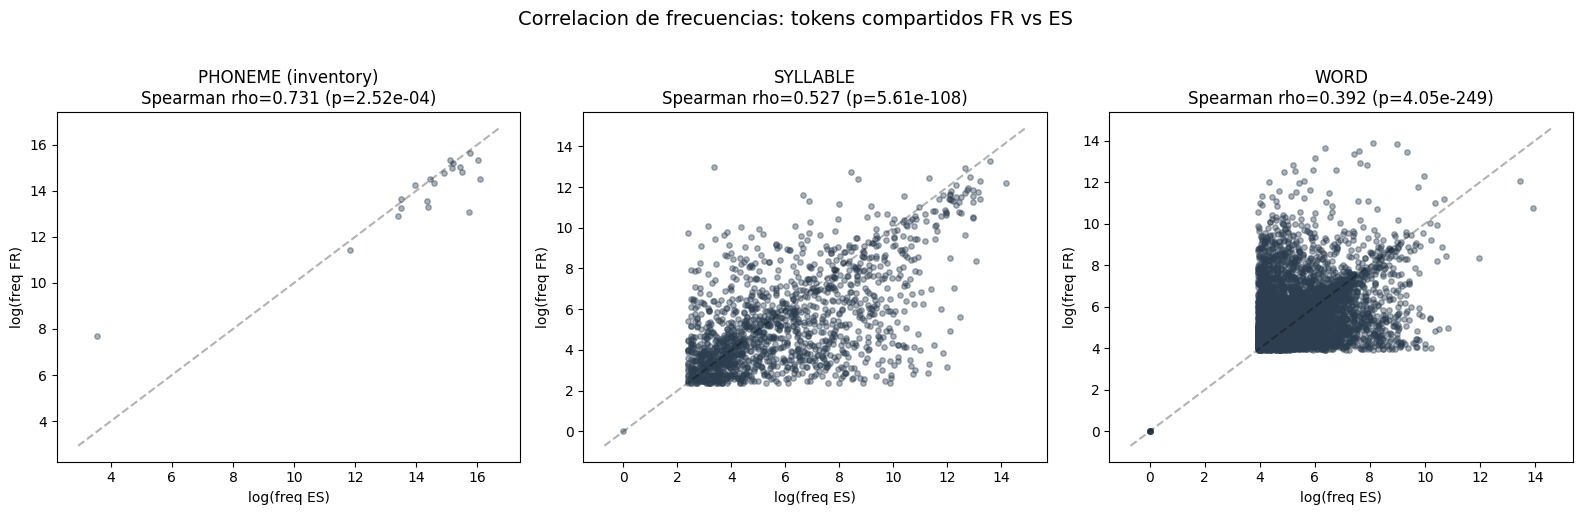

In [8]:
from scipy.stats import spearmanr

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for idx, level in enumerate(("phoneme", "syllable", "word")):
    ax = axes[idx]
    freq_es = freqs[level]["es"].set_index("token")["freq"]
    freq_fr = freqs[level]["fr"].set_index("token")["freq"]
    
    lang_es = "es" if level == "phoneme" else None
    lang_fr = "fr" if level == "phoneme" else None
    common_tokens = sorted(
        get_vocab(models[level]["es"], lang=lang_es)
        & get_vocab(models[level]["fr"], lang=lang_fr)
    )
    
    es_vals = [freq_es.get(t, 0) for t in common_tokens]
    fr_vals = [freq_fr.get(t, 0) for t in common_tokens]
    
    es_log = np.log1p(es_vals)
    fr_log = np.log1p(fr_vals)
    
    rho, p = spearmanr(es_vals, fr_vals)
    
    ax.scatter(es_log, fr_log, alpha=0.4, s=15, c="#2c3e50")
    ax.set_xlabel("log(freq ES)")
    ax.set_ylabel("log(freq FR)")
    title = f"{level.upper()}"
    if level == "phoneme":
        title += " (inventory)"
    ax.set_title(f"{title}\nSpearman rho={rho:.3f} (p={p:.2e})", fontsize=12)
    
    lims = [min(ax.get_xlim()[0], ax.get_ylim()[0]), max(ax.get_xlim()[1], ax.get_ylim()[1])]
    ax.plot(lims, lims, 'k--', alpha=0.3)

plt.suptitle("Correlacion de frecuencias: tokens compartidos FR vs ES", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("freq_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Resumen: datos disponibles para los siguientes pasos

Exportamos los sets de tokens compartidos para uso en los notebooks siguientes.

In [9]:
import json

# Save shared tokens for downstream notebooks
for level in ("phoneme", "syllable", "word"):
    with open(f"shared_{level}_tokens.json", "w", encoding="utf-8") as f:
        json.dump(shared[level], f, ensure_ascii=False, indent=2)
    print(f"Saved {len(shared[level]):,} shared {level} tokens to shared_{level}_tokens.json")

print("\n--- Resumen para pasos siguientes ---")
print(f"Fonemas compartidos (IPA):  {len(shared['phoneme']):>6,}  (base para clustering fonetico y probing)")
print(f"Silabas compartidas:        {len(shared['syllable']):>6,}  (base para RSA y analisis fonestemico)")
print(f"Palabras compartidas:       {len(shared['word']):>6,}  (base para Procrustes alignment)")

Saved 20 shared phoneme tokens to shared_phoneme_tokens.json
Saved 1,497 shared syllable tokens to shared_syllable_tokens.json
Saved 6,827 shared word tokens to shared_word_tokens.json

--- Resumen para pasos siguientes ---
Fonemas compartidos (IPA):      20  (base para clustering fonetico y probing)
Silabas compartidas:         1,497  (base para RSA y analisis fonestemico)
Palabras compartidas:        6,827  (base para Procrustes alignment)
